# Operations Roles: Full Analysis
**Sources:** BLS Occupational Employment and Wage Statistics (OEWS), May 2025 · BLS Employment Projections, 2024–34 · O\*NET 30.2 Database, February 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

PROCESSED = Path('../data/processed')
REPORTS   = Path('../reports')
REPORTS.mkdir(exist_ok=True)

ops = pd.read_parquet(PROCESSED / 'ops_roles.parquet')

CAT_ORDER = [
    'Claims Specialists & Telephone Claims Reps',
    'Customer Service Representatives',
    'Marketing & Communications',
    'Physical Damage Adjusters',
]
CAT_SHORT = {
    'Claims Specialists & Telephone Claims Reps': 'Claims',
    'Customer Service Representatives':           'Customer Service',
    'Marketing & Communications':                 'Marketing & Comms',
    'Physical Damage Adjusters':                  'Physical Damage',
}
PALETTE = {
    'Claims Specialists & Telephone Claims Reps': '#5C1A8F',   # deep violet
    'Customer Service Representatives':           '#A0369A',   # medium purple
    'Marketing & Communications':                 '#D4449A',   # raspberry pink
    'Physical Damage Adjusters':                  '#F2A7D0',   # soft pink
}
ops['cat_short'] = ops['category'].map(CAT_SHORT)
ops['color']     = ops['category'].map(PALETTE)

plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
print(f"Loaded {len(ops)} occupations across {ops['category'].nunique()} categories")

Loaded 18 occupations across 4 categories


---
## Part 1 — Statistics by Category

In [2]:
# ── Category-level aggregate stats ────────────────────────────────────────────
stats = ops.groupby('category').agg(
    roles             = ('title', 'count'),
    total_employment  = ('employment', 'sum'),
    median_wage       = ('annual_median_wage', 'median'),
    mean_wage         = ('annual_mean_wage', 'median'),
    wage_p10          = ('wage_pct10', 'median'),
    wage_p90          = ('wage_pct90', 'median'),
    avg_growth_pct    = ('emp_change_pct', 'mean'),
    total_openings    = ('annual_openings', 'sum'),
    avg_automation    = ('automation_risk', 'mean'),
).reindex(CAT_ORDER).round(2)

stats_display = stats.copy()
stats_display.index = [CAT_SHORT[i] for i in stats_display.index]
stats_display['total_employment'] = stats_display['total_employment'].map('{:,.0f}'.format)
stats_display['median_wage']      = stats_display['median_wage'].map('${:,.0f}'.format)
stats_display['mean_wage']        = stats_display['mean_wage'].map('${:,.0f}'.format)
stats_display['wage_p10']         = stats_display['wage_p10'].map('${:,.0f}'.format)
stats_display['wage_p90']         = stats_display['wage_p90'].map('${:,.0f}'.format)
stats_display['avg_growth_pct']   = stats_display['avg_growth_pct'].map('{:+.1f}%'.format)
stats_display['total_openings']   = stats_display['total_openings'].map('{:,.0f}'.format)
stats_display['avg_automation']   = stats_display['avg_automation'].map('{:.2f}'.format)

stats_display.columns = [
    'Roles', 'Total Employment', 'Median Wage',
    'Mean Wage', 'Wage P10', 'Wage P90',
    'Avg 10yr Growth', 'Annual Openings', 'Avg Automation Risk'
]
print("=== Category Statistics (Sources: BLS OEWS May 2025 · BLS Projections 2024-34 · O*NET 30.2) ===")
stats_display

=== Category Statistics (Sources: BLS OEWS May 2025 · BLS Projections 2024-34 · O*NET 30.2) ===


,Roles,Total Employment,Median Wage,Mean Wage,Wage P10,Wage P90,Avg 10yr Growth,Annual Openings,Avg Automation Risk
Claims,4,"776,040","$79,550","$87,085","$48,655","$131,100",-2.1%,60,0.70
Customer Service,3,"3,581,130","$44,770","$46,590","$31,750","$63,530",-7.6%,478,0.62
Marketing & Comms,8,"2,685,390","$78,760","$89,490","$43,750","$155,480",+3.0%,257,0.38
Physical Damage,3,"11,560","$78,240","$78,900","$58,360","$101,590",-8.2%,0,0.69


In [3]:
# ── Role-level detail table ────────────────────────────────────────────────────
detail = ops[[
    'category', 'soc_code', 'title',
    'employment', 'annual_median_wage', 'emp_change_pct',
    'annual_openings', 'automation_risk',
    'entry_education', 'job_zone',
]].sort_values(['category', 'automation_risk'], ascending=[True, False])

detail['category'] = detail['category'].map(CAT_SHORT)
detail.columns = [
    'Category', 'SOC Code', 'Title',
    'Employment', 'Median Wage ($)', '10yr Growth (%)',
    'Ann. Openings (k)', 'Automation Risk',
    'Typical Entry Education', 'Job Zone',
]
print("=== Role-Level Detail ===")
pd.set_option('display.max_colwidth', 55)
pd.set_option('display.max_rows', 25)
detail.reset_index(drop=True)

=== Role-Level Detail ===


,Category,SOC Code,Title,Employment,Median Wage ($),10yr Growth (%),Ann. Openings (k),Automation Risk,Typical Entry Education,Job Zone
0,Claims,43-9041.00,Insurance Claims and Policy Processing Clerks,214260.0,49230.0,-3.7,20.3,0.7932,High school diploma or equivalent,2.0
1,Claims,13-1031.00,"Claims Adjusters, Examiners, and Investigators",324230.0,78000.0,-5.1,21.1,0.7044,High school diploma or equivalent,4.0
2,Claims,13-2053.00,Insurance Underwriters,105420.0,81370.0,-2.6,8.2,0.6764,Bachelor's degree,4.0
3,Claims,13-2099.04,"Fraud Examiners, Investigators and Analysts",132130.0,81100.0,3.1,10.3,0.6176,Bachelor's degree,4.0
4,Customer Service,43-4151.00,Order Clerks,75200.0,46170.0,-17.2,8.0,0.7038,"Some college, no degree",2.0
5,Customer Service,43-4051.00,Customer Service Representatives,2595750.0,44770.0,-5.5,341.7,0.5961,High school diploma or equivalent,2.0
6,Customer Service,43-4171.00,Receptionists and Information Clerks,910180.0,38010.0,0.0,128.5,0.5544,High school diploma or equivalent,2.0
7,Marketing & Comms,13-1161.00,Market Research Analysts and Marketing Specialists,899580.0,78760.0,6.7,87.2,0.5369,Bachelor's degree,4.0
8,Marketing & Comms,11-2032.00,Public Relations Managers,74850.0,146910.0,5.0,6.6,0.5270,Bachelor's degree,4.0
9,Marketing & Comms,27-3099.00,"Media and Communication Workers, All Other",19590.0,73620.0,2.7,3.0,0.5270,High school diploma or equivalent,NaN


---
## Part 2 — Visualizations

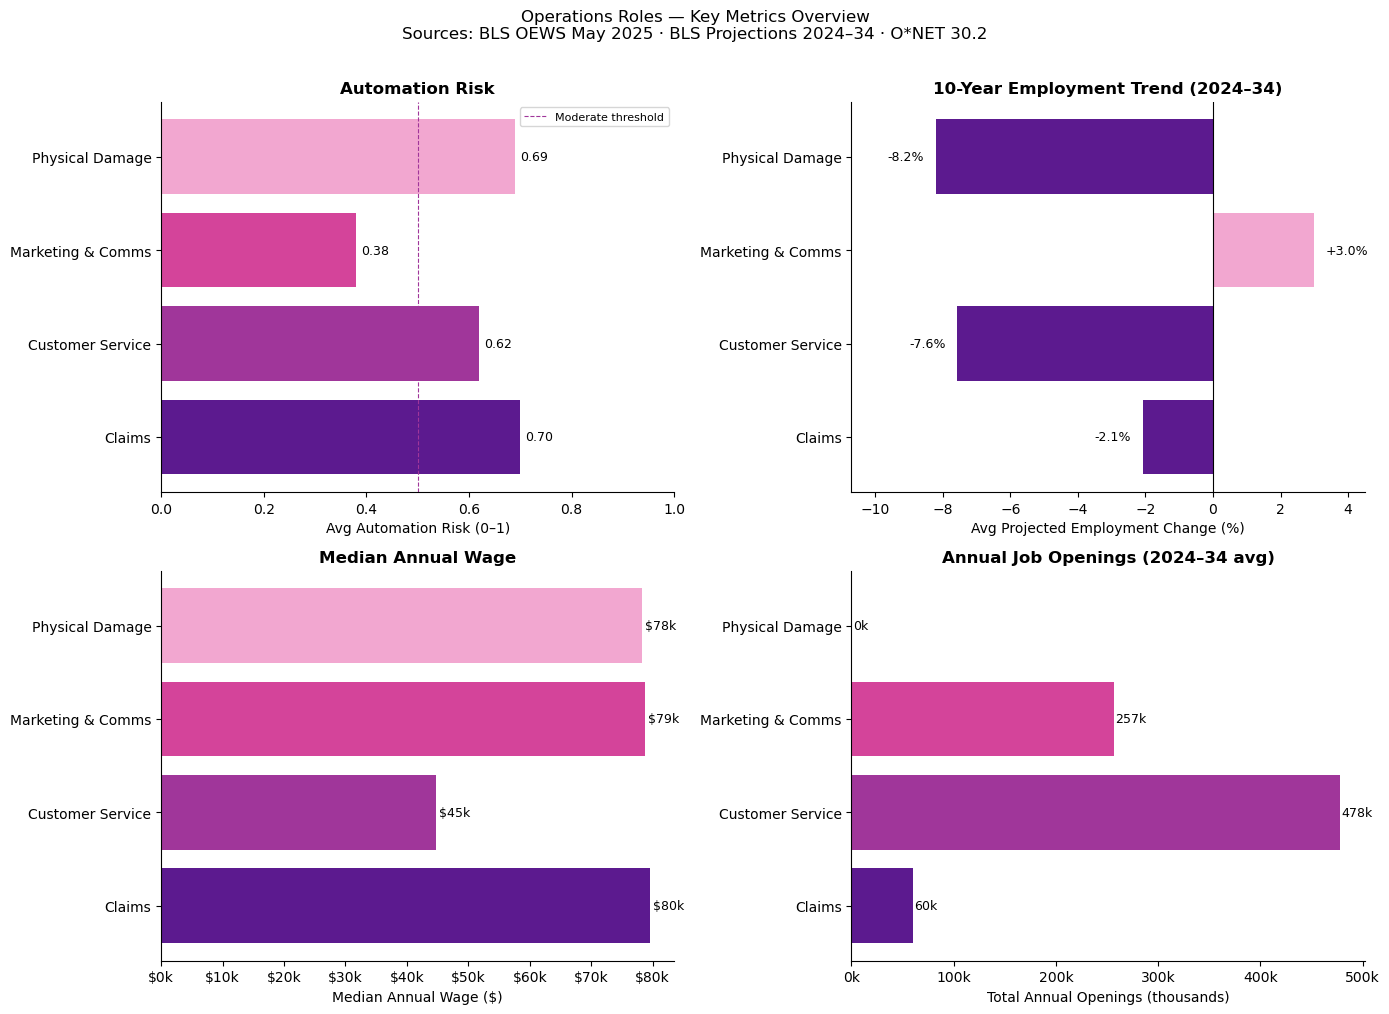

Saved: reports/fig1_overview.png


In [4]:
# ── Fig 1: Four-metric overview (2×2 grid) ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Operations Roles — Key Metrics Overview\nSources: BLS OEWS May 2025 · BLS Projections 2024–34 · O*NET 30.2',
             fontsize=12, y=1.01)

cats_short = [CAT_SHORT[c] for c in CAT_ORDER]
colors     = [PALETTE[c] for c in CAT_ORDER]

# 1a — Automation Risk
ax = axes[0, 0]
vals = [stats.loc[c, 'avg_automation'] for c in CAT_ORDER]
bars = ax.barh(cats_short, vals, color=colors)
ax.axvline(0.5, color='#A0369A', linestyle='--', linewidth=0.8, label='Moderate threshold')
ax.set_xlabel('Avg Automation Risk (0–1)')
ax.set_title('Automation Risk', fontweight='bold')
for bar, v in zip(bars, vals):
    ax.text(v + 0.01, bar.get_y() + bar.get_height()/2, f'{v:.2f}', va='center', fontsize=9)
ax.legend(fontsize=8)
ax.set_xlim(0, 1)

# 1b — 10yr Employment Growth
ax = axes[0, 1]
vals = [stats.loc[c, 'avg_growth_pct'] for c in CAT_ORDER]
bar_colors = ['#5C1A8F' if v < 0 else '#F2A7D0' for v in vals]
bars = ax.barh(cats_short, vals, color=bar_colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Avg Projected Employment Change (%)')
ax.set_title('10-Year Employment Trend (2024–34)', fontweight='bold')
# Labels just outside each bar end; xlim padded to guarantee visibility
pad = 0.35
for bar, v in zip(bars, vals):
    if v < 0:
        ax.text(v - pad, bar.get_y() + bar.get_height()/2, f'{v:+.1f}%',
                va='center', ha='right', fontsize=9)
    else:
        ax.text(v + pad, bar.get_y() + bar.get_height()/2, f'{v:+.1f}%',
                va='center', ha='left', fontsize=9)
x_lo = min(vals) - 2.5
x_hi = max(max(vals), 0) + 1.5
ax.set_xlim(x_lo, x_hi)

# 1c — Median Annual Wage
ax = axes[1, 0]
vals = [stats.loc[c, 'median_wage'] for c in CAT_ORDER]
bars = ax.barh(cats_short, vals, color=colors)
ax.set_xlabel('Median Annual Wage ($)')
ax.set_title('Median Annual Wage', fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
for bar, v in zip(bars, vals):
    if not np.isnan(v):
        ax.text(v + 500, bar.get_y() + bar.get_height()/2, f'${v/1000:.0f}k', va='center', fontsize=9)

# 1d — Annual Job Openings
ax = axes[1, 1]
vals = [stats.loc[c, 'total_openings'] for c in CAT_ORDER]
bars = ax.barh(cats_short, vals, color=colors)
ax.set_xlabel('Total Annual Openings (thousands)')
ax.set_title('Annual Job Openings (2024–34 avg)', fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}k'))
for bar, v in zip(bars, vals):
    if not np.isnan(v):
        ax.text(v + 1, bar.get_y() + bar.get_height()/2, f'{v:.0f}k', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(REPORTS / 'fig1_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reports/fig1_overview.png")

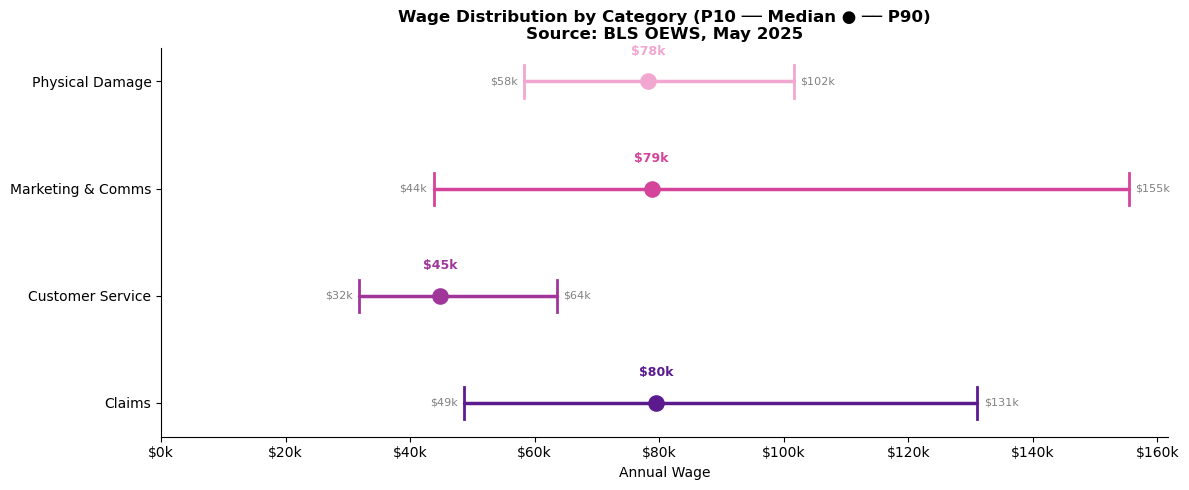

Saved: reports/fig2_wages.png


In [5]:
# ── Fig 2: Wage distribution by category (box-style using percentiles) ────────
fig, ax = plt.subplots(figsize=(12, 5))

y_pos = np.arange(len(CAT_ORDER))
for i, cat in enumerate(CAT_ORDER):
    row  = stats.loc[cat]
    p10  = row['wage_p10']
    p90  = row['wage_p90']
    med  = row['median_wage']
    col  = PALETTE[cat]
    if pd.isna(p10) or pd.isna(p90): continue
    # whisker
    ax.plot([p10, p90], [i, i], color=col, linewidth=2.5, solid_capstyle='round')
    # p10 / p90 ticks
    ax.plot([p10, p10], [i - 0.15, i + 0.15], color=col, linewidth=2)
    ax.plot([p90, p90], [i - 0.15, i + 0.15], color=col, linewidth=2)
    # median dot
    ax.scatter([med], [i], color=col, s=120, zorder=5)
    ax.text(p10 - 1000, i, f'${p10/1000:.0f}k', ha='right', va='center', fontsize=8, color='gray')
    ax.text(p90 + 1000, i, f'${p90/1000:.0f}k', ha='left',  va='center', fontsize=8, color='gray')
    ax.text(med,        i + 0.22, f'${med/1000:.0f}k', ha='center', va='bottom', fontsize=9, fontweight='bold', color=col)

ax.set_yticks(y_pos)
ax.set_yticklabels([CAT_SHORT[c] for c in CAT_ORDER])
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_xlabel('Annual Wage')
ax.set_title('Wage Distribution by Category (P10 ── Median ● ── P90)\nSource: BLS OEWS, May 2025', fontweight='bold')
ax.set_xlim(0, None)

plt.tight_layout()
plt.savefig(REPORTS / 'fig2_wages.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reports/fig2_wages.png")

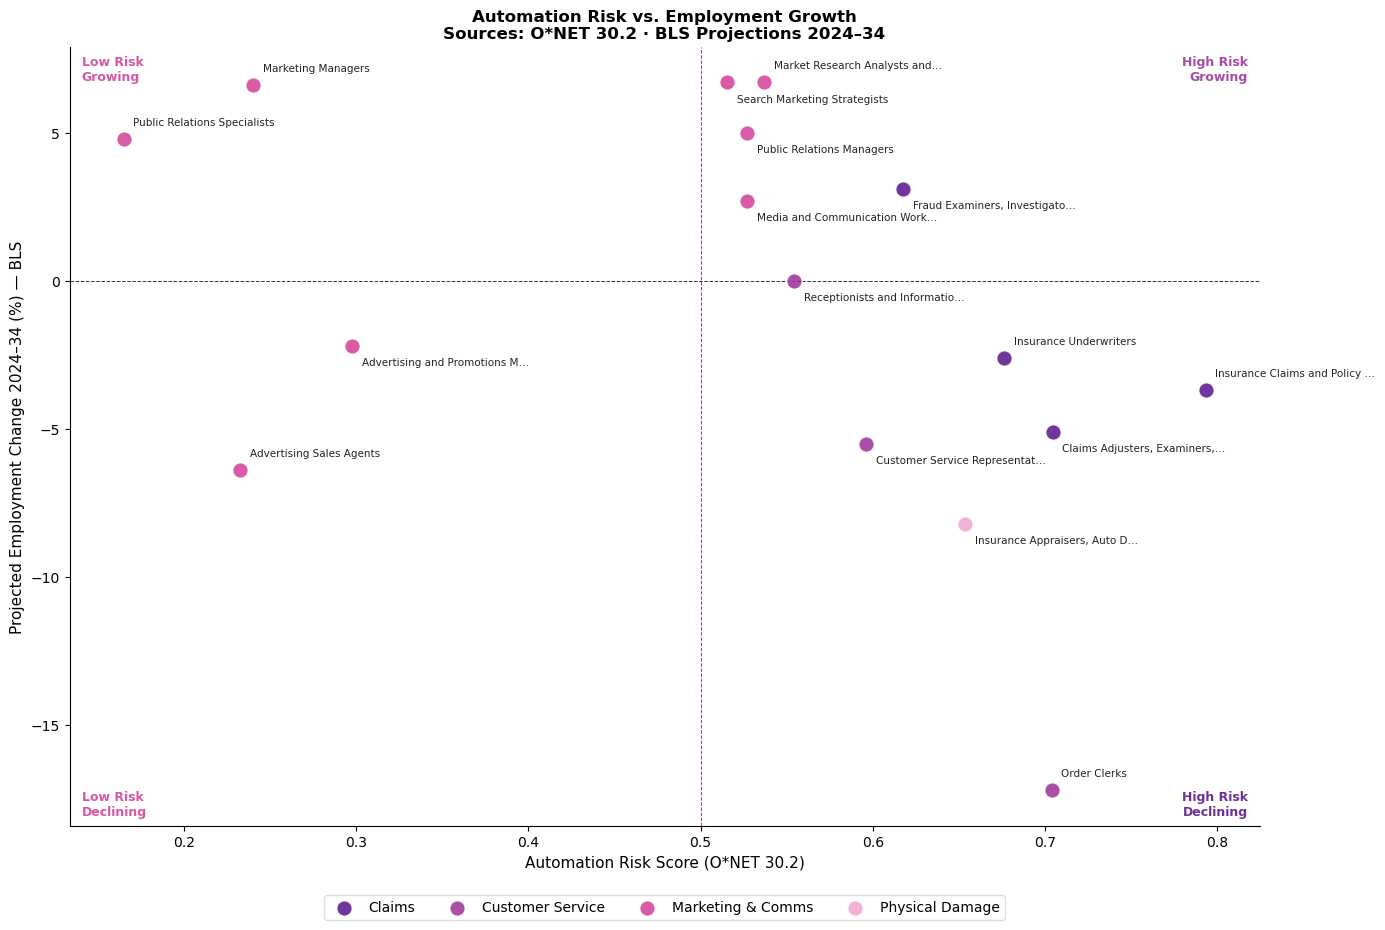

Saved: reports/fig3_risk_vs_growth.png


In [6]:
# ── Fig 3: Role-level scatter — automation risk vs. 10yr growth ───────────────
fig, ax = plt.subplots(figsize=(14, 10))

DOT_SIZE = 120  # uniform across all roles

for cat in CAT_ORDER:
    sub = ops[(ops['category'] == cat) & ops['emp_change_pct'].notna()]
    ax.scatter(
        sub['automation_risk'], sub['emp_change_pct'],
        c=PALETTE[cat], s=DOT_SIZE,
        alpha=0.88, label=CAT_SHORT[cat], edgecolors='white', linewidths=0.8, zorder=3
    )

# Annotations: white background box + alternating above/below to reduce overlap.
# Roles sharing identical coords get opposite horizontal offsets.
seen_coords = {}
for cat in CAT_ORDER:
    sub = ops[(ops['category'] == cat) & ops['emp_change_pct'].notna()].reset_index(drop=True)
    for i, (_, row) in enumerate(sub.iterrows()):
        label = row['title'] if len(row['title']) <= 30 else row['title'][:28] + '…'
        coord_key = (round(row['automation_risk'], 3), round(row['emp_change_pct'], 1))
        dup = coord_key in seen_coords
        seen_coords[coord_key] = seen_coords.get(coord_key, 0) + 1
        xoff = -7 if dup else 7        # push duplicate leftward
        yoff = -14 if (i % 2 == 0 and not dup) else 10
        ax.annotate(
            label,
            xy=(row['automation_risk'], row['emp_change_pct']),
            xytext=(xoff, yoff), textcoords='offset points',
            fontsize=7.5, color='#222', zorder=5,
            bbox=dict(boxstyle='round,pad=0.18', facecolor='white',
                      edgecolor='none', alpha=0.82),
        )

# Reference lines
ax.axhline(0,   color='#333',    linewidth=0.7, linestyle='--', zorder=1)
ax.axvline(0.5, color='#A0369A', linewidth=0.7, linestyle='--', zorder=1)

# Quadrant labels — pinned to the four corners in axes-fraction space
# White bbox ensures they're readable even near data points
_qlabel_kw = dict(transform=ax.transAxes, fontsize=9, fontweight='bold', alpha=0.9,
                  bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.7))
ax.text(0.01, 0.99, 'Low Risk\nGrowing',    color='#D4449A', ha='left',  va='top',    **_qlabel_kw)
ax.text(0.99, 0.99, 'High Risk\nGrowing',   color='#A0369A', ha='right', va='top',    **_qlabel_kw)
ax.text(0.01, 0.01, 'Low Risk\nDeclining',  color='#D4449A', ha='left',  va='bottom', **_qlabel_kw)
ax.text(0.99, 0.01, 'High Risk\nDeclining', color='#5C1A8F', ha='right', va='bottom', **_qlabel_kw)

ax.set_xlabel('Automation Risk Score (O*NET 30.2)', fontsize=11)
ax.set_ylabel('Projected Employment Change 2024–34 (%) — BLS', fontsize=11)
ax.set_title('Automation Risk vs. Employment Growth\nSources: O*NET 30.2 · BLS Projections 2024–34',
             fontweight='bold')

# Legend below the chart
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08),
          ncol=4, fontsize=10, frameon=True, framealpha=0.95, edgecolor='#ddd')

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(REPORTS / 'fig3_risk_vs_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reports/fig3_risk_vs_growth.png")

Using 13/14 features found in O*NET master


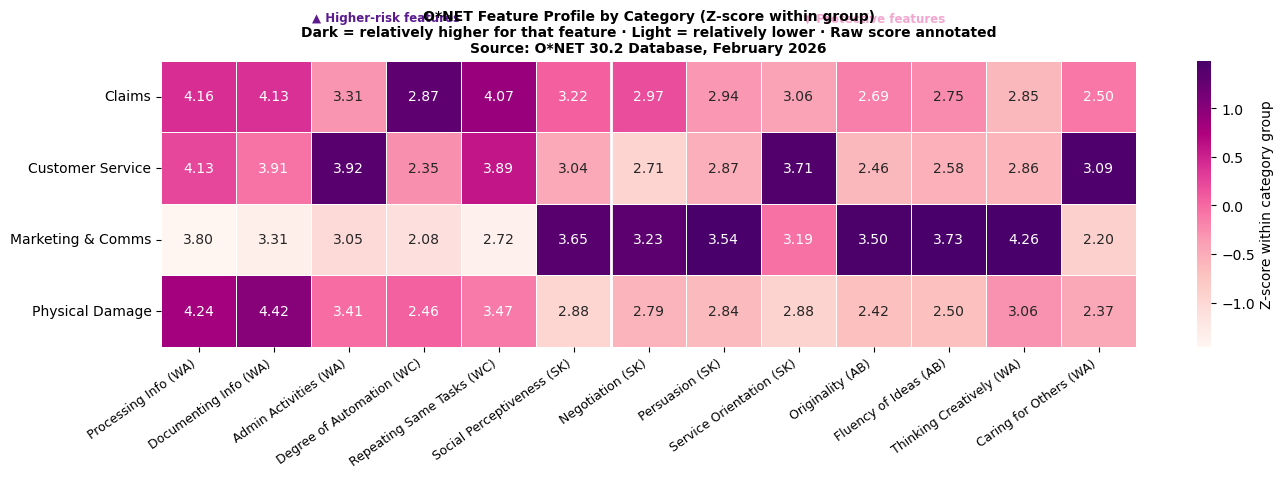

Saved: reports/fig4_onet_features.png


In [7]:
# ── Fig 4: O*NET feature heatmap — what drives automation risk per category ───
feature_map = {
    'Processing Info (WA)':          'work_activity__Processing Information__IM',
    'Documenting Info (WA)':         'work_activity__Documenting/Recording Information__IM',
    'Admin Activities (WA)':         'work_activity__Performing Administrative Activities__IM',
    'Interacting w/ Computers (WA)': 'work_activity__Interacting With Computers__IM',
    'Degree of Automation (WC)':     'work_context__Degree of Automation',
    'Repeating Same Tasks (WC)':     'work_context__Importance of Repeating Same Tasks',
    'Social Perceptiveness (SK)':    'skill__Social Perceptiveness__IM',
    'Negotiation (SK)':              'skill__Negotiation__IM',
    'Persuasion (SK)':               'skill__Persuasion__IM',
    'Service Orientation (SK)':      'skill__Service Orientation__IM',
    'Originality (AB)':              'ability__Originality__IM',
    'Fluency of Ideas (AB)':         'ability__Fluency of Ideas__IM',
    'Thinking Creatively (WA)':      'work_activity__Thinking Creatively__IM',
    'Caring for Others (WA)':        'work_activity__Assisting and Caring for Others__IM',
}

onet_full    = pd.read_parquet(PROCESSED / 'onet_master.parquet')
feature_cols = [v for v in feature_map.values() if v in onet_full.columns]
ops_feat     = ops.merge(onet_full[['soc_code'] + feature_cols], on='soc_code', how='left')

valid_features = {k: v for k, v in feature_map.items() if v in ops_feat.columns}
print(f"Using {len(valid_features)}/{len(feature_map)} features found in O*NET master")

heatmap_data = []
for cat in CAT_ORDER:
    sub = ops_feat[ops_feat['category'] == cat]
    row = {k: sub[v].mean() for k, v in valid_features.items()}
    heatmap_data.append(row)

heat_df = pd.DataFrame(heatmap_data, index=[CAT_SHORT[c] for c in CAT_ORDER])

all_means = heat_df.mean()
all_stds  = heat_df.std().replace(0, 1)
heat_z    = (heat_df - all_means) / all_stds

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    heat_z, annot=heat_df.round(2), fmt='.2f',
    cmap='RdPu', center=0, linewidths=0.5,
    ax=ax, cbar_kws={'label': 'Z-score within category group'}
)

n_high = 6
ax.axvline(n_high, color='white', linewidth=2)
ax.text(n_high / 2,          -0.55, '▲ Higher-risk features', ha='center', fontsize=8.5, color='#5C1A8F', fontweight='bold')
ax.text(n_high + (len(valid_features) - n_high) / 2, -0.55, '▼ Protective features', ha='center', fontsize=8.5, color='#F2A7D0', fontweight='bold')

ax.set_title('O*NET Feature Profile by Category (Z-score within group)\n'
             'Dark = relatively higher for that feature · Light = relatively lower · Raw score annotated\n'
             'Source: O*NET 30.2 Database, February 2026',
             fontsize=10, fontweight='bold')
ax.set_ylabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(REPORTS / 'fig4_onet_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reports/fig4_onet_features.png")

---
## Part 3 — Written Diagnosis by Category

In [8]:
def risk_label(score):
    if score >= 0.68: return 'HIGH'
    if score >= 0.50: return 'MODERATE-HIGH'
    if score >= 0.35: return 'MODERATE'
    return 'LOW'

def growth_label(pct):
    if pct <= -8:  return 'rapidly declining'
    if pct <= -3:  return 'declining'
    if pct <=  2:  return 'stagnant'
    if pct <=  6:  return 'growing'
    return 'fast-growing'

def top_features(cat, n=3):
    sub   = ops_feat[ops_feat['category'] == cat]
    means = {k: sub[v].mean() for k, v in valid_features.items()}
    z     = {k: (v - all_means[k]) / all_stds[k] for k, v in means.items()}
    high_keys = list(valid_features.keys())[:6]
    low_keys  = list(valid_features.keys())[6:]
    high  = sorted([(k, v) for k, v in z.items() if k in high_keys], key=lambda x: x[1], reverse=True)[:n]
    low   = sorted([(k, v) for k, v in z.items() if k in low_keys],  key=lambda x: x[1])[:n]
    return [f[0] for f in high], [f[0] for f in low]

diagnoses = {}

for cat in CAT_ORDER:
    s         = stats.loc[cat]
    rl        = risk_label(s['avg_automation'])
    gl        = growth_label(s['avg_growth_pct'])
    hi_feat, lo_feat = top_features(cat)
    roles_str = ', '.join(ops[ops['category'] == cat]['title'].tolist())

    diagnosis = f"""
{'='*70}
CATEGORY: {CAT_SHORT[cat]}
{'='*70}

ROLES ANALYZED
  {roles_str}

KEY STATISTICS  (Sources: BLS OEWS May 2025 · BLS Projections 2024–34)
  Total Employment    : {s['total_employment']:>10,.0f} workers
  Median Annual Wage  : {s['median_wage']:>10,.0f} USD
  Wage Range (P10–P90): ${s['wage_p10']:,.0f} – ${s['wage_p90']:,.0f}
  10-Year Job Growth  : {s['avg_growth_pct']:>+.1f}% (2024–2034)
  Annual Job Openings : {s['total_openings']:>10,.0f}

AUTOMATION RISK  (Source: O*NET 30.2 Database, February 2026)
  Score: {s['avg_automation']:.2f} / 1.00  →  {rl}
  Top automatable task signals : {', '.join(hi_feat)}
  Top protective task signals  : {', '.join(lo_feat) if lo_feat else 'None identified'}

MARKET TREND
  Employment outlook is {gl} at {s['avg_growth_pct']:+.1f}%.
  Annual openings of {s['total_openings']:,.0f} are {'mostly replacement demand' if s['avg_growth_pct'] < 0 else 'a mix of growth and replacement demand'}.

DIAGNOSIS"""

    if rl in ('HIGH', 'MODERATE-HIGH') and s['avg_growth_pct'] < 0:
        narrative = (
            f"  {CAT_SHORT[cat]} sits in the most vulnerable quadrant: high automation exposure "
            f"combined with a {gl} employment outlook. The dominant task profile — "
            f"{hi_feat[0].lower()} and {hi_feat[1].lower() if len(hi_feat)>1 else ''} — "
            f"is well within the current capability of AI-assisted workflows and RPA tools. "
            f"Structural headcount reduction is already reflected in the BLS projections "
            f"and is likely to accelerate as AI tooling matures. Roles in this category "
            f"should be prioritised for reskilling or transition planning."
        )
    elif rl in ('HIGH', 'MODERATE-HIGH') and s['avg_growth_pct'] >= 0:
        narrative = (
            f"  {CAT_SHORT[cat]} carries high automation risk but still shows {gl} "
            f"employment. This suggests current human workforce is still needed — possibly "
            f"due to implementation lag — but the structural conditions for displacement "
            f"are present. Monitor closely for inflection as AI adoption in this function matures."
        )
    elif rl == 'MODERATE' and s['avg_growth_pct'] >= 0:
        narrative = (
            f"  {CAT_SHORT[cat]} shows a relatively resilient profile. Moderate automation "
            f"exposure is offset by meaningful protective signals — particularly "
            f"{lo_feat[0].lower() if lo_feat else 'human-centric tasks'} — which are harder "
            f"to fully automate. The {gl} employment outlook reinforces that demand remains "
            f"healthy. Investment in upskilling toward strategic and analytical capabilities "
            f"would further insulate this category."
        )
    else:
        narrative = (
            f"  {CAT_SHORT[cat]} presents a mixed picture — {gl} employment paired with "
            f"{rl.lower()} automation risk. While protective task signals "
            f"({lo_feat[0].lower() if lo_feat else 'human judgment'}) provide some buffer, "
            f"the declining market trend warrants attention. Roles may need to evolve "
            f"to emphasise higher-complexity tasks to remain viable."
        )

    diagnosis += '\n' + narrative + '\n'
    diagnoses[cat] = diagnosis
    print(diagnosis)


CATEGORY: Claims

ROLES ANALYZED
  Claims Adjusters, Examiners, and Investigators, Insurance Underwriters, Fraud Examiners, Investigators and Analysts, Insurance Claims and Policy Processing Clerks

KEY STATISTICS  (Sources: BLS OEWS May 2025 · BLS Projections 2024–34)
  Total Employment    :    776,040 workers
  Median Annual Wage  :     79,550 USD
  Wage Range (P10–P90): $48,655 – $131,100
  10-Year Job Growth  : -2.1% (2024–2034)
  Annual Job Openings :         60

AUTOMATION RISK  (Source: O*NET 30.2 Database, February 2026)
  Score: 0.70 / 1.00  →  HIGH
  Top automatable task signals : Degree of Automation (WC), Repeating Same Tasks (WC), Processing Info (WA)
  Top protective task signals  : Thinking Creatively (WA), Service Orientation (SK), Persuasion (SK)

MARKET TREND
  Employment outlook is stagnant at -2.1%.
  Annual openings of 60 are mostly replacement demand.

DIAGNOSIS
  Claims sits in the most vulnerable quadrant: high automation exposure combined with a stagnant emplo

---
## Part 4 — Save Full Report

In [9]:
# Save written report as text file
report_lines = [
    'OPERATIONS ROLES ANALYSIS REPORT',
    'Sources: BLS OEWS May 2025 · BLS Employment Projections 2024–34 · O*NET 30.2 (February 2026)',
    '=' * 70,
]
for cat in CAT_ORDER:
    report_lines.append(diagnoses[cat])

report_path = REPORTS / 'operations_roles_report.txt'
with open(report_path, 'w') as f:
    f.write('\n'.join(report_lines))

# Save stats table as CSV
stats_display.to_csv(REPORTS / 'category_stats.csv')
detail.to_csv(REPORTS / 'role_detail.csv', index=False)

print('Saved to reports/:')
for p in sorted(REPORTS.iterdir()):
    print(f'  {p.name}')

Saved to reports/:
  .gitkeep
  category_stats.csv
  fig1_overview.png
  fig2_wages.png
  fig3_risk_vs_growth.png
  fig4_onet_features.png
  operations_roles_report.txt
  role_detail.csv
